In [9]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain_openrouter import ChatOpenRouter
from langchain_google_genai import ChatGoogleGenerativeAI

from pathlib import Path
import re
import os
import dotenv
import time

dotenv.load_dotenv()

MODEL = "gemini-3.5-flash-lite"

In [10]:
# Find all .html files in the given directory and print their paths and parent directory names

from pathlib import Path

html_paths = list(Path("../dry_runs/inputs/").rglob("*.html"))

for html_path in html_paths:
    dir_name = html_path.parent.name
    print(f"Directory: {dir_name}, HTML Path: @{html_path}")

Directory: deepseek-v4-pro, HTML Path: @../dry_runs/inputs/deepseek-v4-pro/world.html
Directory: kimi-k-3, HTML Path: @../dry_runs/inputs/kimi-k-3/world.html
Directory: kimi-k-2-7, HTML Path: @../dry_runs/inputs/kimi-k-2-7/world.html
Directory: gemini-3-6-flash, HTML Path: @../dry_runs/inputs/gemini-3-6-flash/world.html
Directory: deepseek-v4-flash, HTML Path: @../dry_runs/inputs/deepseek-v4-flash/world.html
Directory: grok-4-5-fast, HTML Path: @../dry_runs/inputs/grok-4-5-fast/world.html
Directory: opus-5, HTML Path: @../dry_runs/inputs/opus-5/world.html
Directory: qwen-3-8-max-prev, HTML Path: @../dry_runs/inputs/qwen-3-8-max-prev/world.html
Directory: gemini-3-1-pro, HTML Path: @../dry_runs/inputs/gemini-3-1-pro/world.html
Directory: fable, HTML Path: @../dry_runs/inputs/fable/world.html
Directory: gpt-5-6-sol, HTML Path: @../dry_runs/inputs/gpt-5-6-sol/world.html
Directory: glm-5-turbo, HTML Path: @../dry_runs/inputs/glm-5-turbo/world.html


In [11]:
#1 strip the chunks from the given world.html 

file = html_paths[0]

def strip_html(html_path: str) -> str:

    raw = Path(html_path).read_text(encoding="utf-8", errors="ignore")

    # 1. Drop CSS — never contains placement
    no_css = re.sub(r"<style\b[^>]*>.*?</style>", "", raw, flags=re.I | re.S)

    # 2. Keep only <script> bodies (inline JS)
    scripts = re.findall(r"<script\b[^>]*>(.*?)</script>", no_css, flags=re.I | re.S)
    js = "\n\n".join(s.strip() for s in scripts if s.strip())

    # 3. Optional: drop import maps / CDN-only empty scripts
    return js

chunks = strip_html(file)

print(chunks)


{
            "imports": {
                "three": "https://unpkg.com/three@0.160.0/build/three.module.js",
                "three/addons/": "https://unpkg.com/three@0.160.0/examples/jsm/"
            }
        }

import * as THREE from 'three';
        import { OrbitControls } from 'three/addons/controls/OrbitControls.js';

        // ────────────────────────────────────
        // SCENE SETUP
        // ────────────────────────────────────
        const scene = new THREE.Scene();
        scene.background = new THREE.Color(0x000000);
        scene.fog = new THREE.Fog(0x000000, 120, 300);

        const renderer = new THREE.WebGLRenderer({ antialias: true });
        renderer.setPixelRatio(Math.min(window.devicePixelRatio, 2));
        renderer.setSize(window.innerWidth, window.innerHeight);
        renderer.shadowMap.enabled = true;
        renderer.shadowMap.type = THREE.PCFSoftShadowMap;
        renderer.toneMapping = THREE.ACESFilmicToneMapping;
        renderer.toneMappingExposur

In [14]:
#2 find the biome in the chunks
class BiomeBlock(BaseModel):
    present: bool
    aliases: list[str] = []
    placement_code: str = ""
    elevation_code: str = ""

class ClassifiedBiomeJS(BaseModel):
    biomes: dict[str, BiomeBlock]

CLASSIFIER_PROMPT = """
Task: From SOURCE (inline JS of a Three.js island), extract biome-layout code.

Canonical ids (every key required):
mountains, forest, highlands, jungle, swamp, grove, grassland, delta, desert, volcano

Return JSON only:
{
  "biomes": {
    "<id>": {
      "present": true|false,
      "aliases": ["SOURCE_TOKEN"],
      "placement_code": "<verbatim JS that places this biome in XZ>",
      "elevation_code": "<verbatim JS that sets this biome's height>"
    }
  }
}

Rules:
- Emit all 10 keys. Never omit.
- present false → aliases [], both code fields "".
- Copy lines only, no paraphrase. No neighbors. No scene/lights/trees/colors.
- ocean/beach/coast → delta. conifer/pine/taiga → forest. plains → grassland.
Return ClassifiedBiomeJS JSON only.
"""  

def classify_biome_js(html_path: str, model: str) -> ClassifiedBiomeJS:
    js = strip_html(html_path)
    client = ChatGoogleGenerativeAI(  # whatever you constructed
        model=model,
        max_retries=0,
    )
    llm = client.with_structured_output(ClassifiedBiomeJS, include_raw=True, method="json_schema")
    t0 = time.monotonic()
    classified = llm.invoke(CLASSIFIER_PROMPT + "\n\nSOURCE:\n" + js)
    print(f"[classify] done in {time.monotonic() - t0:.1f}s", flush=True)
    return classified
classified = classify_biome_js(file, MODEL)
# print(classified.placement_style)
# print(classified.blocks.biome_assignment[:500])

[classify] done in 5.0s


In [15]:
print(classified["raw"].model_dump_json(indent=2))

{
  "content": [
    {
      "type": "text",
      "text": "{\n  \"biomes\": {\n    \"mountains\": {\n      \"present\": true,\n      \"aliases\": [\n        \"snow_mountain\",\n        \"snow_rock\"\n      ],\n      \"placement_code\": \"if (z < -38 && h > 18) return 'snow_mountain';\\n            if (z < -38 && h > 10) return 'snow_rock';\",\n      \"elevation_code\": \"h += gaussian(x, z, -12, -48, 16, 12, 38);\\n            h += ridgeGaussian(x, z, -8, -52, 20, 7, 22, -0.3);\\n            h += gaussian(x, z, -20, -44, 10, 8, 25);\\n            h += gaussian(x, z, -4, -40, 9, 9, 18);\"\n    },\n    \"forest\": {\n      \"present\": true,\n      \"aliases\": [\n        \"conifer_forest\"\n      ],\n      \"placement_code\": \"if (z < -20 && z > -38 && x < 5 && x > -28 && h > 7) return 'conifer_forest';\",\n      \"elevation_code\": \"h += gaussian(x, z, -10, -30, 14, 10, 16);\\n            h += gaussian(x, z, -18, -28, 8, 7, 10);\"\n    },\n    \"highlands\": {\n      \"present\": tr

In [16]:
print(classified["parsed"].model_dump_json(indent=2))

{
  "biomes": {
    "mountains": {
      "present": true,
      "aliases": [
        "snow_mountain",
        "snow_rock"
      ],
      "placement_code": "if (z < -38 && h > 18) return 'snow_mountain';\n            if (z < -38 && h > 10) return 'snow_rock';",
      "elevation_code": "h += gaussian(x, z, -12, -48, 16, 12, 38);\n            h += ridgeGaussian(x, z, -8, -52, 20, 7, 22, -0.3);\n            h += gaussian(x, z, -20, -44, 10, 8, 25);\n            h += gaussian(x, z, -4, -40, 9, 9, 18);"
    },
    "forest": {
      "present": true,
      "aliases": [
        "conifer_forest"
      ],
      "placement_code": "if (z < -20 && z > -38 && x < 5 && x > -28 && h > 7) return 'conifer_forest';",
      "elevation_code": "h += gaussian(x, z, -10, -30, 14, 10, 16);\n            h += gaussian(x, z, -18, -28, 8, 7, 10);"
    },
    "highlands": {
      "present": true,
      "aliases": [
        "highlands"
      ],
      "placement_code": "if (x > 18 && x < 40 && z > -35 && z < -15 && h 

In [18]:
#Step 2: Making a graph out of the processed data

#3 extract graph from classified JSON (standalone)
from collections import defaultdict
from typing import Literal
from pydantic import BaseModel, Field

BiomeId = Literal[
    "mountains", "forest", "highlands", "jungle", "swamp",
    "grove", "grassland", "delta", "desert", "volcano",
]
BIOME_LABELS = {
    "mountains": "Snow Mountains",
    "forest": "Snowy Conifer Forest",
    "highlands": "Highlands",
    "jungle": "Dense Jungle",
    "swamp": "Backwater Swamp",
    "grove": "Flowering Grove",
    "grassland": "Grassland Plateau",
    "delta": "Coastal Delta / Ocean",
    "desert": "Desert Basin",
    "volcano": "Volcano",
}
RULES = {
    "mountains": {"must_connect": ["forest"], "higher_than": ["forest", "highlands", "jungle", "grassland", "delta"]},
    "forest": {"must_connect": ["mountains", "highlands"], "higher_than": ["highlands", "jungle", "grassland", "delta"]},
    "highlands": {"must_connect": ["forest", "jungle"], "higher_than": ["jungle", "grassland", "delta"]},
    "jungle": {"must_connect": ["highlands", "grassland", "swamp"], "higher_than": ["grassland", "delta"]},
    "swamp": {"must_connect": ["jungle"], "must_not_connect": ["delta"]},
    "grove": {"must_connect_any": ["highlands", "grassland"]},
    "grassland": {"must_connect": ["jungle", "delta"], "higher_than": ["delta"]},
    "delta": {"must_connect": ["grassland"]},
    "desert": {"must_not_connect": ["mountains", "forest", "highlands", "jungle", "delta"]},
    "volcano": {"must_not_connect": ["mountains", "forest", "highlands", "grassland", "delta"]},
}

class BiomeNode(BaseModel):
    id: BiomeId
    neighbors: list[BiomeId]
    evidence: str

class ExtractedGraph(BaseModel):
    nodes: list[BiomeNode]
    elevation_order: list[BiomeId]

pack = classified["parsed"] if isinstance(classified, dict) else classified
biome_list = "\n".join(f"- {i}: {n}" for i, n in BIOME_LABELS.items())

EXTRACT_PROMPT = f"""
This is per-biome layout JS from a Three.js island.
Canonical ids (id: label):
{biome_list}

For each biome with present=true, use placement_code and elevation_code only.
For present=false: neighbors=[], evidence="not in source". Do not invent from ecology.

Return JSON only:
{{
  "nodes": [
    {{
      "id": "mountains"|"forest"|"highlands"|"jungle"|"swamp"|"grove"|"grassland"|"delta"|"desert"|"volcano",
      "neighbors": ["<canonical_id>"],
      "evidence": "<code / coordinate / generation clue>"
    }}
  ],
  "elevation_order": ["<id>", "<id>", "<id>", "<id>", "<id>", "<id>", "<id>", "<id>", "<id>", "<id>"]
}}

Rules:
- nodes: all 10 ids. neighbors = biomes that touch in XZ (boxes, centers, region edges).
- elevation_order: all 10 ids, highest altitude to lowest, from elevation_code numbers — not real-world elevation.
- present=false ids go last in elevation_order.
"""

client = ChatGoogleGenerativeAI(model=MODEL, max_retries=0)
llm = client.with_structured_output(ExtractedGraph, include_raw=True, method="json_schema")

t0 = time.monotonic()
payload = llm.invoke(EXTRACT_PROMPT + "\n\nBIOMES:\n" + pack.model_dump_json())
print(f"[extract] done in {time.monotonic() - t0:.1f}s", flush=True)

raw, graph, err = payload["raw"], payload["parsed"], payload["parsing_error"]
um = raw.usage_metadata or {}
print("tokens in/out/total:", um.get("input_tokens"), um.get("output_tokens"), um.get("total_tokens"))
if graph is None:
    raise ValueError(f"parse failed: {err}\n{raw.content}")

print(graph.model_dump_json(indent=2))



[extract] done in 2.9s
tokens in/out/total: 1794 808 2602
{
  "nodes": [
    {
      "id": "mountains",
      "neighbors": [
        "forest",
        "highlands",
        "volcano"
      ],
      "evidence": "if (z < -38 && h > 18) return 'snow_mountain';"
    },
    {
      "id": "forest",
      "neighbors": [
        "mountains",
        "highlands",
        "jungle",
        "volcano"
      ],
      "evidence": "if (z < -20 && z > -38 && x < 5 && x > -28 && h > 7) return 'conifer_forest';"
    },
    {
      "id": "highlands",
      "neighbors": [
        "mountains",
        "forest",
        "grove",
        "volcano"
      ],
      "evidence": "if (x > 18 && x < 40 && z > -35 && z < -15 && h > 8) return 'highlands';"
    },
    {
      "id": "jungle",
      "neighbors": [
        "forest",
        "swamp",
        "grassland",
        "volcano"
      ],
      "evidence": "if (x > -22 && x < 10 && z > -20 && z < 5 && h < 10 && vdist > 15) return 'jungle';"
    },
    {
      "id"

In [19]:
# 3. Deterministic grade
adj = defaultdict(set)
for node in graph.nodes:
    for n in node.neighbors:
        adj[node.id].add(n)
        adj[n].add(node.id)
rank = {b: i for i, b in enumerate(graph.elevation_order)}

def grade_one(bid, rules):
    for req in rules.get("must_connect", []):
        if req not in adj.get(bid, set()):
            return False, f"not connected to {req}"
    if "must_connect_any" in rules:
        opts = rules["must_connect_any"]
        if not any(o in adj.get(bid, set()) for o in opts):
            return False, f"not connected to any of {opts}"
    for bad in rules.get("must_not_connect", []):
        if bad in adj.get(bid, set()):
            return False, f"incorrectly connected to {bad}"
    for hi in rules.get("higher_than", []):
        if bid not in rank or hi not in rank:
            return False, f"missing elevation data for {bid} or {hi}"
        if rank[bid] >= rank[hi]:
            return False, f"not at a higher elevation than {hi}"
    return True, "ok"

found, missing = {}, {}
for bid, rules in RULES.items():
    ok, why = grade_one(bid, rules)
    (found if ok else missing)[bid] = why

print(f"score={len(found)}/{len(RULES)}  missing={list(missing)}")
print(missing)

score=4/10  missing=['forest', 'highlands', 'jungle', 'swamp', 'desert', 'volcano']
{'forest': 'not at a higher elevation than highlands', 'highlands': 'not connected to jungle', 'jungle': 'not connected to highlands', 'swamp': 'incorrectly connected to delta', 'desert': 'incorrectly connected to delta', 'volcano': 'incorrectly connected to mountains'}


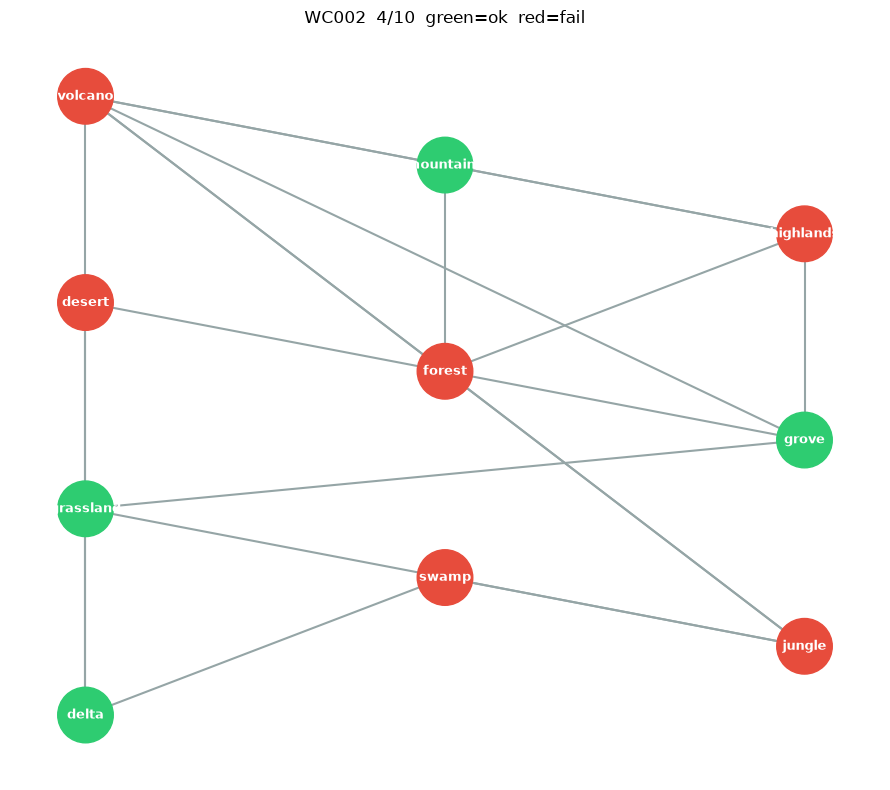

green: ['mountains', 'grove', 'grassland', 'delta']
red:   {'forest': 'not at a higher elevation than highlands', 'highlands': 'not connected to jungle', 'jungle': 'not connected to highlands', 'swamp': 'incorrectly connected to delta', 'desert': 'incorrectly connected to delta', 'volcano': 'incorrectly connected to mountains'}


In [20]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.Graph()
for node in graph.nodes:
    G.add_node(node.id)
    for n in node.neighbors:
        G.add_edge(node.id, n)

# y = elevation (highest at top); x = spread so labels don't overlap
order = list(graph.elevation_order)
rank = {b: i for i, b in enumerate(order)}
pos = {}
for i, b in enumerate(order):
    pos[b] = ((i % 3) - 1.0, -rank.get(b, 9))

colors = ["#2ecc71" if b in found else "#e74c3c" for b in G.nodes()]

fig, ax = plt.subplots(figsize=(9, 8))
nx.draw_networkx(
    G, pos=pos, ax=ax,
    node_color=colors, node_size=1600,
    font_size=9, font_color="white", font_weight="bold",
    edge_color="#95a5a6", width=1.5,
)
ax.set_title(f"WC002  {len(found)}/10  green=ok  red=fail")
ax.axis("off")
plt.tight_layout()
plt.show()

print("green:", list(found))
print("red:  ", missing)